# Kalman Filter — Voetbal Teamsterkte via xG

## Stap 1 — Imports en data laden

In [1]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

import pandas as pd
import numpy as np

df = pd.read_csv('training_data_with_xg.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

df_xg = df[df['home_xg'].notna()].copy().reset_index(drop=True)
print(f'Wedstrijden met xG: {len(df_xg)}')
df_xg[['timestamp','home_team','away_team','home_xg','away_xg']].head()

Wedstrijden met xG: 2581


,timestamp,home_team,away_team,home_xg,away_xg
0,2019-08-09 19:00:00,Liverpool,Norwich City,2.234560,0.842407
1,2019-08-10 11:30:00,West Ham United,Manchester City,1.200300,3.183770
2,2019-08-10 14:00:00,Bournemouth,Sheffield United,1.340990,1.598640
3,2019-08-10 14:00:00,Burnley,Southampton,0.909241,1.087520
4,2019-08-10 14:00:00,Watford,Brighton & Hove Albion,0.670022,0.855516


## Stap 2 — Hyperparameters instellen

Dit zijn de vier knoppen die je kunt draaien:
- **PHI**: hoe persistent is teamsterkte? (0.99 = traag veranderend)
- **SIGMA_W**: procesruis — hoe snel mag sterkte veranderen?
- **SIGMA_V**: meetruis — hoeveel ruis zit er in xG als meting?
- **DELTA**: thuisvoordeel in xG

In [10]:
PHI     = 0.9990
SIGMA_W = 0.0363
SIGMA_V = 0.7559
DELTA   = 0.15
BETA_LINEUP = 0.2

## Stap 3 — Kalman Filter

Het model per wedstrijd:
```
home_xg = DELTA + alpha_home - gamma_away + ruis
away_xg =         alpha_away - gamma_home + ruis
```

Per team houden we bij:
- `alpha`: aanvalskracht
- `gamma`: verdedigingskracht
- `var_alpha` / `var_gamma`: onzekerheid daarover

In [11]:
PHI     = 0.9990
SIGMA_W = 0.0363
SIGMA_V = 0.7559
DELTA   = 0.15
BETA_LINEUP = 0.2

teams = sorted(set(df_xg['home_team']) | set(df_xg['away_team']))

alpha     = {t: 0.0 for t in teams}
gamma     = {t: 0.0 for t in teams}
var_alpha = {t: 1.0 for t in teams}
var_gamma = {t: 1.0 for t in teams}

results = []

for _, row in df_xg.iterrows():
    h = row['home_team']
    a = row['away_team']

    # Lineup verschil — hoe veel sterker is de thuisopstelling?
    lineup_h = row.get('home_lineup_strength', 0)
    lineup_a = row.get('away_lineup_strength', 0)
    lineup_diff = lineup_h - lineup_a

    # ── 1. PREDICT ──────────────────────────────────
    a_h = PHI * alpha[h];     a_a = PHI * alpha[a]
    g_h = PHI * gamma[h];     g_a = PHI * gamma[a]

    va_h = PHI**2 * var_alpha[h] + SIGMA_W**2
    va_a = PHI**2 * var_alpha[a] + SIGMA_W**2
    vg_h = PHI**2 * var_gamma[h] + SIGMA_W**2
    vg_a = PHI**2 * var_gamma[a] + SIGMA_W**2

    # ── 2. OBSERVATIE ───────────────────────────────
    # Lineup correctie toegevoegd aan verwachte xG
    xg_h_pred = DELTA + a_h - g_a + BETA_LINEUP * lineup_diff
    xg_a_pred =         a_a - g_h - BETA_LINEUP * lineup_diff

    e_h = row['home_xg'] - xg_h_pred
    e_a = row['away_xg'] - xg_a_pred

    S_h = va_h + vg_a + SIGMA_V**2
    S_a = va_a + vg_h + SIGMA_V**2

    # ── 3. KALMAN GAIN ──────────────────────────────
    K_alpha_h = va_h / S_h;   K_gamma_a = vg_a / S_h
    K_alpha_a = va_a / S_a;   K_gamma_h = vg_h / S_a

    # ── 4. UPDATE ───────────────────────────────────
    alpha[h] = a_h + K_alpha_h * e_h
    alpha[a] = a_a + K_alpha_a * e_a
    gamma[a] = g_a - K_gamma_a * e_h
    gamma[h] = g_h - K_gamma_h * e_a

    var_alpha[h] = (1 - K_alpha_h) * va_h
    var_alpha[a] = (1 - K_alpha_a) * va_a
    var_gamma[a] = (1 - K_gamma_a) * vg_a
    var_gamma[h] = (1 - K_gamma_h) * vg_h

    # Pre-match state opslaan
    results.append({
        'match_id':              row['match_id'],
        'timestamp':             row['timestamp'],
        'home_team':             h,
        'away_team':             a,
        'home_xg':               row['home_xg'],
        'away_xg':               row['away_xg'],
        'home_lineup_strength':  lineup_h,
        'away_lineup_strength':  lineup_a,
        'lineup_diff':           lineup_diff,
        'kalman_alpha_home':     a_h,
        'kalman_gamma_home':     g_h,
        'kalman_alpha_away':     a_a,
        'kalman_gamma_away':     g_a,
        'kalman_attack_diff':    a_h - a_a,
        'kalman_defense_diff':   g_h - g_a,
        # xG pred inclusief lineup correctie
        'kalman_xg_pred_home':   xg_h_pred,
        'kalman_xg_pred_away':   xg_a_pred,
        'kalman_xg_pred_diff':   xg_h_pred - xg_a_pred,
        # xG pred zonder lineup (voor vergelijking)
        'kalman_xg_pred_home_raw': DELTA + a_h - g_a,
        'kalman_xg_pred_away_raw':         a_a - g_h,
    })

kalman_df = pd.DataFrame(results)

# Vergelijk met en zonder lineup
print('=== EFFECT VAN LINEUP CORRECTIE ===')
print(f'xG pred home — met lineup: {kalman_df["kalman_xg_pred_home"].mean():.3f}')
print(f'xG pred home — zonder:     {kalman_df["kalman_xg_pred_home_raw"].mean():.3f}')
print(f'Werkelijke home xG:         {kalman_df["home_xg"].mean():.3f}')
print()
print(f'xG pred away — met lineup: {kalman_df["kalman_xg_pred_away"].mean():.3f}')
print(f'xG pred away — zonder:     {kalman_df["kalman_xg_pred_away_raw"].mean():.3f}')
print(f'Werkelijke away xG:         {kalman_df["away_xg"].mean():.3f}')
print()

# Correlatie lineup diff met xG verschil
corr = kalman_df['lineup_diff'].corr(kalman_df['home_xg'] - kalman_df['away_xg'])
print(f'Correlatie lineup_diff vs werkelijk xG verschil: {corr:.3f}')
print(f'(hoger = lineup is goede voorspeller van xG verschil)')

=== EFFECT VAN LINEUP CORRECTIE ===
xG pred home — met lineup: 1.539
xG pred home — zonder:     1.539
Werkelijke home xG:         1.636

xG pred away — met lineup: 1.396
xG pred away — zonder:     1.396
Werkelijke away xG:         1.360

Correlatie lineup_diff vs werkelijk xG verschil: 0.488
(hoger = lineup is goede voorspeller van xG verschil)


## Stap 4 — Visualiseer teamsterktes over de tijd

Als het filter goed werkt zie je sterke teams (Liverpool, Man City) consistent hoog, zwakke teams laag.

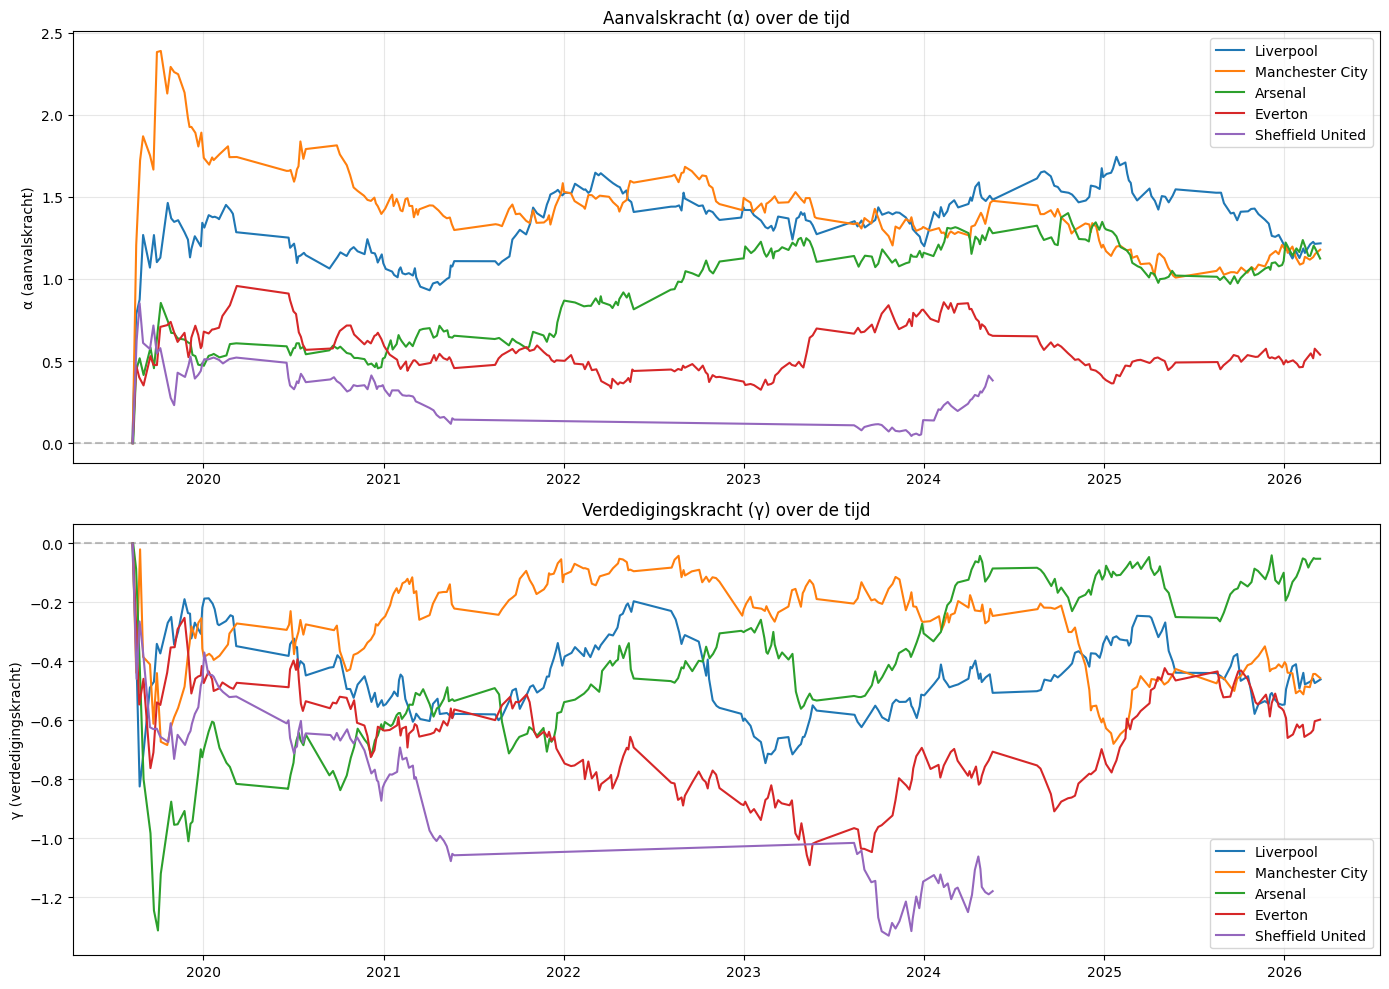

Plot opgeslagen als kalman_teamsterktes.png


In [12]:
import matplotlib.pyplot as plt

teams_to_plot = ['Liverpool', 'Manchester City', 'Arsenal', 'Everton', 'Sheffield United']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for team in teams_to_plot:
    # Wedstrijden als thuisteam
    home_games = kalman_df[kalman_df['home_team'] == team][['timestamp','kalman_alpha_home']].rename(columns={'kalman_alpha_home':'alpha'})
    # Wedstrijden als uitteam
    away_games = kalman_df[kalman_df['away_team'] == team][['timestamp','kalman_alpha_away']].rename(columns={'kalman_alpha_away':'alpha'})
    team_alpha = pd.concat([home_games, away_games]).sort_values('timestamp')
    axes[0].plot(team_alpha['timestamp'], team_alpha['alpha'], label=team)

axes[0].set_title('Aanvalskracht (α) over de tijd')
axes[0].set_ylabel('α (aanvalskracht)')
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

for team in teams_to_plot:
    home_games = kalman_df[kalman_df['home_team'] == team][['timestamp','kalman_gamma_home']].rename(columns={'kalman_gamma_home':'gamma'})
    away_games = kalman_df[kalman_df['away_team'] == team][['timestamp','kalman_gamma_away']].rename(columns={'kalman_gamma_away':'gamma'})
    team_gamma = pd.concat([home_games, away_games]).sort_values('timestamp')
    axes[1].plot(team_gamma['timestamp'], team_gamma['gamma'], label=team)

axes[1].set_title('Verdedigingskracht (γ) over de tijd')
axes[1].set_ylabel('γ (verdedigingskracht)')
axes[1].legend()
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_teamsterktes.png', dpi=150)
plt.show()
print('Plot opgeslagen als kalman_teamsterktes.png')

## Stap 5 — Evaluatie: kan Kalman de winnaar voorspellen?

Eenvoudige test: als `kalman_xg_pred_home > kalman_xg_pred_away`, voorspellen we thuiswinst.

In [13]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Werkelijk resultaat
eval_df = kalman_df.merge(
    df_xg[['match_id','home_goals','away_goals']],
    on='match_id'
)

def actual_result(row):
    if row['home_goals'] > row['away_goals']:  return 'H'
    elif row['home_goals'] < row['away_goals']: return 'A'
    else:                                       return 'D'

def predicted_result(row):
    if row['kalman_xg_pred_home'] > row['kalman_xg_pred_away'] + 0.1:  return 'H'
    elif row['kalman_xg_pred_home'] < row['kalman_xg_pred_away'] - 0.1: return 'A'
    else:                                                                return 'D'

eval_df['actual']    = eval_df.apply(actual_result, axis=1)
eval_df['predicted'] = eval_df.apply(predicted_result, axis=1)

# Sla eerste ~100 wedstrijden over (filter heeft dan pas data)
eval_df = eval_df.iloc[100:]

acc = accuracy_score(eval_df['actual'], eval_df['predicted'])
f1  = f1_score(eval_df['actual'], eval_df['predicted'], average='macro')

print(f'Accuracy:  {acc:.3f}')
print(f'F1 (macro): {f1:.3f}')
print(f'\nConfusion matrix:')
print(pd.crosstab(eval_df['actual'], eval_df['predicted'], margins=True))

Accuracy:  0.538
F1 (macro): 0.454

Confusion matrix:
predicted    A    D     H   All
actual                         
A          510   78   240   828
D          236   59   283   578
H          232   78   765  1075
All        978  215  1288  2481


## Stap 6 — Opslaan voor gebruik in XGBoost

In [15]:
# Merge Kalman features terug in de volledige trainingsdata
kalman_features = kalman_df[[
    'match_id',
    'kalman_alpha_home', 'kalman_gamma_home',
    'kalman_alpha_away', 'kalman_gamma_away',
    'kalman_attack_diff', 'kalman_defense_diff',
    'kalman_xg_pred_home', 'kalman_xg_pred_away',
    'kalman_xg_pred_diff',
]]

df_final = df.merge(kalman_features, on='match_id', how='left')

df_final.to_csv('training_data_with_kalman.csv', index=False)
print(f'Opgeslagen als training_data_with_kalman.csv')
print(f'Kalman kolommen toegevoegd: {list(kalman_features.columns[1:])}')
print(f'Wedstrijden met Kalman features: {df_final["kalman_alpha_home"].notna().sum()}')

Opgeslagen als training_data_with_kalman.csv
Kalman kolommen toegevoegd: ['kalman_alpha_home', 'kalman_gamma_home', 'kalman_alpha_away', 'kalman_gamma_away', 'kalman_attack_diff', 'kalman_defense_diff', 'kalman_xg_pred_home', 'kalman_xg_pred_away', 'kalman_xg_pred_diff']
Wedstrijden met Kalman features: 2581
